# RPL Attack Detection — Per-Stratum Analysis (Issue 8)

This notebook runs the **per-stratum feature-reduction analysis** (Section 8.3.4 of the report).
It evaluates whether the SHAP/RFE/MI top-7 feature recommendation holds across all five attack classes.

**Run cells in order: 1 → 2 → 3 → 4 → 5**

| Cell | Contents |
|------|----------|
| 1 | Imports and configuration |
| 2 | Utility functions |
| 3 | Load engineered dataset |
| 4 | Compute SHAP, RFE, and MI feature rankings |
| 5 | Per-stratum evaluation — produces Table 3c, Figure 10, Figure 11 |

**Prerequisites:** Run FeatureEng.ipynb first.


In [1]:
# Cell 1 — Imports and configuration

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import tracemalloc
from scipy.stats import spearmanr, kendalltau, wilcoxon
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score
from sklearn.ensemble import (RandomForestClassifier,
                               GradientBoostingClassifier,
                               VotingClassifier)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
import shap
from sklearn.feature_selection import RFE, mutual_info_classif
import warnings
import os
import time
from datetime import datetime

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')

TRAIN_PATH     = "iot_rpl_engineered_train.csv"
TEST_PATH      = "iot_rpl_engineered_test.csv"
LABEL_COL      = "label"
TRAIN_SAMPLE   = 100_000
TEST_SAMPLE    = 50_000
SEEDS = list(range(42, 52))
N_BOOT         = 10_000
GAUSSIAN_SIGMA = 0.05

FEATURE_COLS   = [
    'roll_total', 'roll_n_DIS', 'roll_n_DIO', 'roll_n_DAO',
    'roll_ratio_DIS', 'roll_ratio_DIO', 'roll_ratio_DAO',
    'roll_unique_to', 'roll_avg_doagid2', 'roll_avg_doagid3',
    'roll_avg_dio', 'roll_avg_obj', 'roll_avg_life'
]
SUBSET_SIZES   = [3, 5, 7, 10, 13]
SIGMA_SWEEP    = [0.05, 0.1, 0.2, 0.5]

In [2]:
# Cell 2 — Utility functions

def bootstrap_ci(scores, n_boot=N_BOOT, ci=95):
    scores = np.array(scores)
    if len(scores) == 1:
        return scores[0], scores[0], scores[0]
    boot  = np.random.choice(scores, size=(n_boot, len(scores)), replace=True)
    means = boot.mean(axis=1)
    lo    = np.percentile(means, (100 - ci) / 2)
    hi    = np.percentile(means, 100 - (100 - ci) / 2)
    return scores.mean(), lo, hi


def ci_str(scores):
    m, lo, hi = bootstrap_ci(scores)
    return f"{m:.4f} [{lo:.4f}, {hi:.4f}]"


def wilcoxon_test(a, b):
    try:
        _, p = wilcoxon(a, b)
        return p
    except Exception:
        return np.nan


def stratified_sample(X, y, n, seed):
    sss = StratifiedShuffleSplit(n_splits=1, train_size=n, random_state=seed)
    idx, _ = next(sss.split(X, y))
    return X[idx], y[idx]


def measure_inference_time(model, X, n_repeats=10):
    """Inference time in microseconds per sample."""
    times = []
    for _ in range(n_repeats):
        t0 = time.perf_counter()
        model.predict(X)
        times.append(time.perf_counter() - t0)
    return (np.mean(times) / len(X)) * 1e6


def measure_model_size(model):
    """Model size in KB."""
    return len(pickle.dumps(model)) / 1024


def measure_peak_memory(model, X_tr, y_tr, sw=None):
    """Peak RSS memory in MB consumed during model.fit() (tracemalloc)."""
    tracemalloc.start()
    if sw is not None:
        model.fit(X_tr, y_tr, sample_weight=sw)
    else:
        model.fit(X_tr, y_tr)
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return peak / 1024 / 1024


def fresh_xgb(seed):
    return XGBClassifier(random_state=seed, eval_metric='mlogloss',
                         tree_method='hist', n_jobs=-1, verbosity=0)

def fresh_rf(seed):
    return RandomForestClassifier(random_state=seed, n_estimators=100, n_jobs=-1)

def fresh_voting(seed):
    return VotingClassifier(
        estimators=[
            ('rf',  RandomForestClassifier(random_state=seed,
                                           n_estimators=100, n_jobs=-1)),
            ('xgb', XGBClassifier(random_state=seed, eval_metric='mlogloss',
                                  tree_method='hist', n_jobs=-1, verbosity=0)),
            ('gb',  GradientBoostingClassifier(random_state=seed))
        ], voting='soft'
    )

def fresh_rf_weighted(seed):
    return RandomForestClassifier(random_state=seed, n_estimators=100,
                                   class_weight='balanced', n_jobs=-1)


def fresh_voting_weighted(seed):
    return VotingClassifier(
        estimators=[
            ('rf',  RandomForestClassifier(random_state=seed, n_estimators=100,
                                           class_weight='balanced', n_jobs=-1)),
            ('xgb', XGBClassifier(random_state=seed, eval_metric='mlogloss',
                                  tree_method='hist', n_jobs=-1, verbosity=0)),
            ('gb',  GradientBoostingClassifier(random_state=seed))
        ], voting='soft'
    )


def fresh_model(name, seed, weighted=False):
    if 'Voting' in name:
        return fresh_voting_weighted(seed) if weighted else fresh_voting(seed)
    elif 'XGBoost' in name:
        return fresh_xgb(seed)   # XGBoost uses sample_weight at fit time
    else:
        return fresh_rf_weighted(seed) if weighted else fresh_rf(seed)


def gaussian_oversample(X, y, std=GAUSSIAN_SIGMA, seed=42):
    np.random.seed(seed)
    classes, counts = np.unique(y, return_counts=True)
    max_n = counts.max()
    Xl, yl = [X], [y]
    for cls, cnt in zip(classes, counts):
        if cnt < max_n:
            Xc  = X[y == cls]
            idx = np.random.choice(len(Xc), max_n - cnt, replace=True)
            Xl.append(Xc[idx] + np.random.normal(0, std, Xc[idx].shape))
            yl.append(np.full(max_n - cnt, cls))
    return np.vstack(Xl), np.concatenate(yl)


def apply_resampling(tech_name, X_tr, y_tr, seed, sigma=GAUSSIAN_SIGMA):
    if tech_name == 'No Resampling':
        return X_tr, y_tr, None, False
    elif tech_name == 'Gaussian Noise':
        X_res, y_res = gaussian_oversample(X_tr, y_tr, std=sigma, seed=seed)
        return X_res, y_res, None, False
    elif tech_name == 'Class Weighted':
        cls_counts  = np.bincount(y_tr)
        cls_weights = 1.0 / cls_counts
        sw = cls_weights[y_tr]
        sw = sw / sw.sum() * len(y_tr)
        return X_tr, y_tr, sw, True   # True = use class_weight="balanced" for RF/Voting
    elif tech_name == 'SMOTE':
        min_cnt   = np.bincount(y_tr).min()
        k         = min(5, min_cnt - 1)
        resampler = SMOTE(random_state=seed, k_neighbors=k)
        X_res, y_res = resampler.fit_resample(X_tr, y_tr)
        return X_res, y_res, None, False
    elif tech_name == 'ADASYN':
        min_cnt   = np.bincount(y_tr).min()
        n         = min(5, min_cnt - 1)
        resampler = ADASYN(random_state=seed, n_neighbors=n)
        X_res, y_res = resampler.fit_resample(X_tr, y_tr)
        return X_res, y_res, None, False
    elif tech_name == 'Random Undersample':
        resampler    = RandomUnderSampler(random_state=seed)
        X_res, y_res = resampler.fit_resample(X_tr, y_tr)
        return X_res, y_res, None, False
    else:
        raise ValueError(f"Unknown technique: {tech_name}")


def save_df(df, results_dir, filename):
    path = os.path.join(results_dir, f"{filename}.xlsx")
    df.to_excel(path, index=False)
    print(f"  Saved: {path}")


def save_fig(results_dir, filename):
    path = os.path.join(results_dir, f"{filename}.pdf")
    plt.savefig(path, dpi=300, bbox_inches='tight')
    print(f"  Saved: {path}")




In [3]:
# Cell 3 — Load engineered dataset

def load_data():
    print("=" * 80)
    print("LOADING IoT-RPL 2021 ENGINEERED DATASET")
    print("=" * 80)

    df_train = pd.read_csv(TRAIN_PATH, low_memory=False)
    df_test  = pd.read_csv(TEST_PATH,  low_memory=False)

    le = LabelEncoder()
    le.fit(pd.concat([df_train[LABEL_COL], df_test[LABEL_COL]]))

    X_train_full = df_train[FEATURE_COLS].values.astype(np.float32)
    y_train_full = le.transform(df_train[LABEL_COL])
    X_test_full  = df_test[FEATURE_COLS].values.astype(np.float32)
    y_test_full  = le.transform(df_test[LABEL_COL])

    X_test, y_test = stratified_sample(X_test_full, y_test_full,
                                        TEST_SAMPLE, seed=0)
    scaler = StandardScaler()
    scaler.fit(X_train_full)
    X_test_scaled = scaler.transform(X_test)

    print(f"  Full train   : {X_train_full.shape}")
    print(f"  Full test    : {X_test_full.shape}")
    print(f"  Test sample  : {X_test_scaled.shape}  (fixed, seed=0)")
    print(f"  Classes      : {list(le.classes_)}")
    print(f"  Seeds        : {SEEDS}")
    print(f"  Train/seed   : {TRAIN_SAMPLE:,}")
    print(f"\n  Natural class distribution (full train):")
    for cls, cnt in zip(*np.unique(y_train_full, return_counts=True)):
        lbl = le.inverse_transform([cls])[0]
        print(f"    {str(lbl).ljust(12)}: {cnt:,}  ({cnt/len(y_train_full)*100:.1f}%)")

    return X_train_full, y_train_full, X_test_scaled, y_test, scaler, le




# Run the loader and store results in module-level variables
X_train_full, y_train_full, X_test, y_test, scaler, le = load_data()
feature_names = FEATURE_COLS
results_dir   = f"RPL_Results_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
os.makedirs(results_dir, exist_ok=True)
print(f'Results directory: {results_dir}')

LOADING IoT-RPL 2021 ENGINEERED DATASET
  Full train   : (8207136, 13)
  Full test    : (2035049, 13)
  Test sample  : (50000, 13)  (fixed, seed=0)
  Classes      : ['Blackhole', 'Flooding', 'Normal', 'Rank', 'Version']
  Seeds        : [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]
  Train/seed   : 100,000

  Natural class distribution (full train):
    Blackhole   : 1,454,839  (17.7%)
    Flooding    : 2,861,729  (34.9%)
    Normal      : 1,713,832  (20.9%)
    Rank        : 1,022,883  (12.5%)
    Version     : 1,153,853  (14.1%)
Results directory: RPL_Results_20260517_162543



PHASE 2: FEATURE RANKINGS (fixed subsample, seed=42)

  SHAP ranking...
             Feature      SHAP
0   roll_avg_doagid3  0.039144
1     roll_unique_to  0.038747
2       roll_avg_obj  0.024166
3     roll_ratio_DIO  0.023091
4       roll_avg_dio  0.022843
5         roll_n_DIO  0.020982
6     roll_ratio_DIS  0.019422
7         roll_n_DIS  0.016457
8   roll_avg_doagid2  0.015453
9     roll_ratio_DAO  0.015446
10     roll_avg_life  0.015320
11        roll_n_DAO  0.015041
12        roll_total  0.000162

  RFE ranking...
             Feature  RFE_Rank
0   roll_avg_doagid3         1
1       roll_avg_obj         2
2         roll_n_DIO         3
3       roll_avg_dio         4
4     roll_unique_to         5
5     roll_ratio_DIO         6
6      roll_avg_life         7
7     roll_ratio_DIS         8
8   roll_avg_doagid2         9
9         roll_n_DAO        10
10        roll_n_DIS        11
11    roll_ratio_DAO        12
12        roll_total        13

  Mutual Information ranking...
        

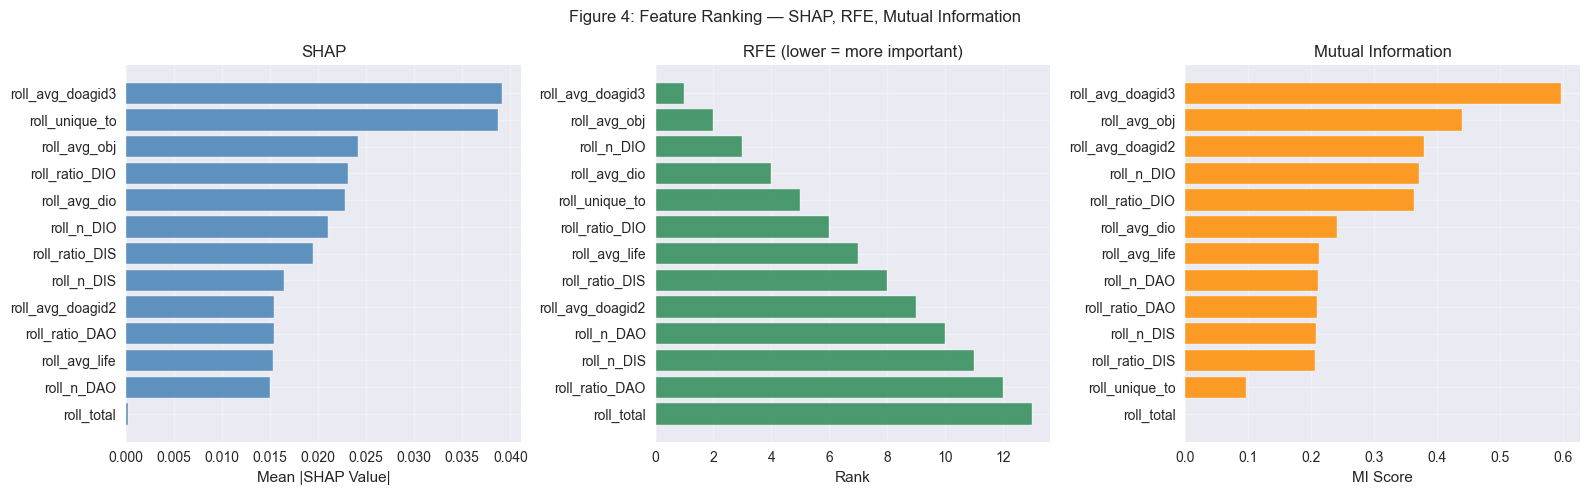

In [4]:
# Cell 4 — Compute feature rankings (SHAP, RFE, Mutual Information)
# Required for Cell 5.

def run_feature_rankings(X_train_full, y_train_full, X_test, y_test,
                          scaler, feature_names, results_dir):
    print("\n" + "=" * 80)
    print("PHASE 2: FEATURE RANKINGS (fixed subsample, seed=42)")
    print("=" * 80)

    X_s_raw, y_s = stratified_sample(X_train_full, y_train_full, 50_000, 42)
    X_s = scaler.transform(X_s_raw)

    # SHAP
    print("\n  SHAP ranking...")
    rf = fresh_rf(42)
    rf.fit(X_s, y_s)
    explainer = shap.TreeExplainer(rf)
    sv        = explainer.shap_values(X_test[:min(2000, len(X_test))])
    if isinstance(sv, list):
        mean_abs = np.mean([np.abs(s).mean(axis=0) for s in sv], axis=0)
    elif len(sv.shape) == 3:
        mean_abs = np.abs(sv).mean(axis=(0, 2))
    else:
        mean_abs = np.abs(sv).mean(axis=0)

    shap_df = (pd.DataFrame({'Feature': feature_names, 'SHAP': mean_abs})
               .sort_values('SHAP', ascending=False)
               .reset_index(drop=True))
    print(shap_df.to_string())
    shap_ranking = shap_df['Feature'].tolist()

    # RFE
    print("\n  RFE ranking...")
    rfe = RFE(RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1),
              n_features_to_select=1, step=1)
    rfe.fit(X_s, y_s)
    rfe_df = (pd.DataFrame({'Feature': feature_names, 'RFE_Rank': rfe.ranking_})
              .sort_values('RFE_Rank')
              .reset_index(drop=True))
    print(rfe_df.to_string())
    rfe_ranking = rfe_df['Feature'].tolist()

    # Mutual Information
    print("\n  Mutual Information ranking...")
    mi    = mutual_info_classif(X_s, y_s, random_state=42)
    mi_df = (pd.DataFrame({'Feature': feature_names, 'MI': mi})
             .sort_values('MI', ascending=False)
             .reset_index(drop=True))
    print(mi_df.to_string())
    mi_ranking = mi_df['Feature'].tolist()

    # Ranking correlations — Issue 7
    print("\n  RANKING CORRELATIONS (Spearman rho + Kendall tau):")

    def to_pos(ranking):
        return [ranking.index(f) + 1 for f in feature_names]

    shap_pos = to_pos(shap_ranking)
    rfe_pos  = to_pos(rfe_ranking)
    mi_pos   = to_pos(mi_ranking)

    pairs = [('SHAP', 'RFE',        shap_pos, rfe_pos),
             ('SHAP', 'MutualInfo', shap_pos, mi_pos),
             ('RFE',  'MutualInfo', rfe_pos,  mi_pos)]
    corr_rows = []
    print(f"\n  {'Pair'.ljust(28)} Spearman rho    Kendall tau")
    for m1, m2, p1, p2 in pairs:
        rho, rho_p = spearmanr(p1, p2)
        tau, tau_p = kendalltau(p1, p2)
        label  = f"{m1} vs {m2}"
        interp = ('Strong'   if abs(rho) > 0.8 else
                  'Moderate' if abs(rho) > 0.5 else 'Weak')
        print(f"  {label.ljust(28)} rho={rho:.4f}(p={rho_p:.3f})  "
              f"tau={tau:.4f}(p={tau_p:.3f})  [{interp}]")
        corr_rows.append({'Method Pair': label,
                          'Spearman rho': round(rho,   4),
                          'Spearman p':   round(rho_p, 4),
                          'Kendall tau':  round(tau,   4),
                          'Kendall p':    round(tau_p, 4),
                          'Interpretation': interp})
    save_df(pd.DataFrame(corr_rows), results_dir, "Table5_Ranking_Correlations")

    # Figure 4
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    axes[0].barh(shap_df['Feature'][::-1], shap_df['SHAP'][::-1],
                 color='steelblue', alpha=0.85)
    axes[0].set_title('SHAP')
    axes[0].set_xlabel('Mean |SHAP Value|')
    axes[0].grid(True, alpha=0.3)

    axes[1].barh(rfe_df['Feature'][::-1], rfe_df['RFE_Rank'][::-1],
                 color='seagreen', alpha=0.85)
    axes[1].set_title('RFE (lower = more important)')
    axes[1].set_xlabel('Rank')
    axes[1].grid(True, alpha=0.3)

    axes[2].barh(mi_df['Feature'][::-1], mi_df['MI'][::-1],
                 color='darkorange', alpha=0.85)
    axes[2].set_title('Mutual Information')
    axes[2].set_xlabel('MI Score')
    axes[2].grid(True, alpha=0.3)

    plt.suptitle('Figure 4: Feature Ranking — SHAP, RFE, Mutual Information',
                 fontsize=12)
    plt.tight_layout()
    save_fig(results_dir, "Figure4_Feature_Ranking_Comparison")
    plt.show()

    return ({'SHAP': shap_ranking, 'RFE': rfe_ranking, 'MutualInfo': mi_ranking},
            shap_df, rfe_df, mi_df)




# Run the feature rankings (needed for Issue 8)
rankings, shap_df, rfe_df, mi_df = run_feature_rankings(
    X_train_full, y_train_full, X_test, y_test,
    scaler, FEATURE_COLS, results_dir)


ISSUE 8 — PER-STRATUM FEATURE-REDUCTION ANALYSIS
  Models       : ['Random Forest', 'XGBoost', 'Soft Voting']
  Methods      : ['SHAP', 'RFE', 'MutualInfo']
  Subset sizes : [3, 5, 7, 10, 13]
  Seeds        : [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]

  [20/450]  method=SHAP  n=3  model=XGBoost  seed=51  — ETA 32.8 min
  [40/450]  method=SHAP  n=5  model=Random Forest  seed=51  — ETA 114.5 min
  [60/450]  method=SHAP  n=5  model=Soft Voting  seed=51  — ETA 193.5 min
  [80/450]  method=SHAP  n=7  model=XGBoost  seed=51  — ETA 159.0 min
  [100/450]  method=SHAP  n=10  model=Random Forest  seed=51  — ETA 193.6 min
  [120/450]  method=SHAP  n=10  model=Soft Voting  seed=51  — ETA 219.2 min
  [140/450]  method=SHAP  n=13  model=XGBoost  seed=51  — ETA 180.9 min
  [160/450]  method=RFE  n=3  model=Random Forest  seed=51  — ETA 166.2 min
  [180/450]  method=RFE  n=3  model=Soft Voting  seed=51  — ETA 145.2 min
  [200/450]  method=RFE  n=5  model=XGBoost  seed=51  — ETA 123.0 min
  [220/450]  

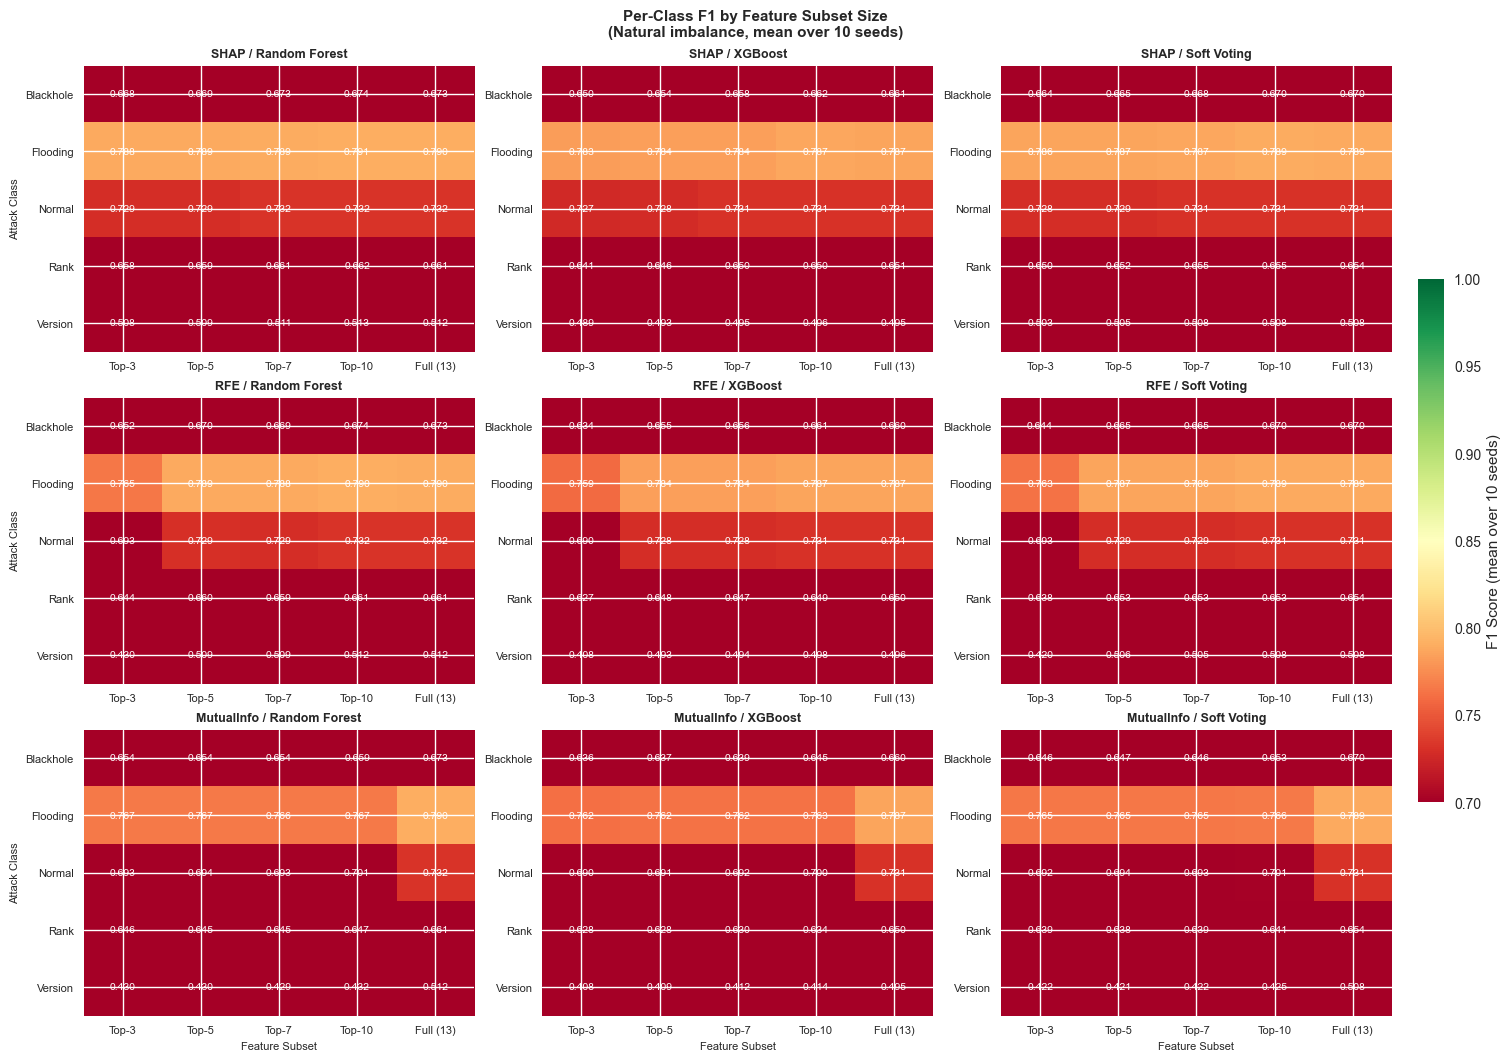

  Generating Figure_Per_Stratum_Subset7 …
  Saved: RPL_Results_20260517_162543\Figure_Per_Stratum_Subset7.pdf


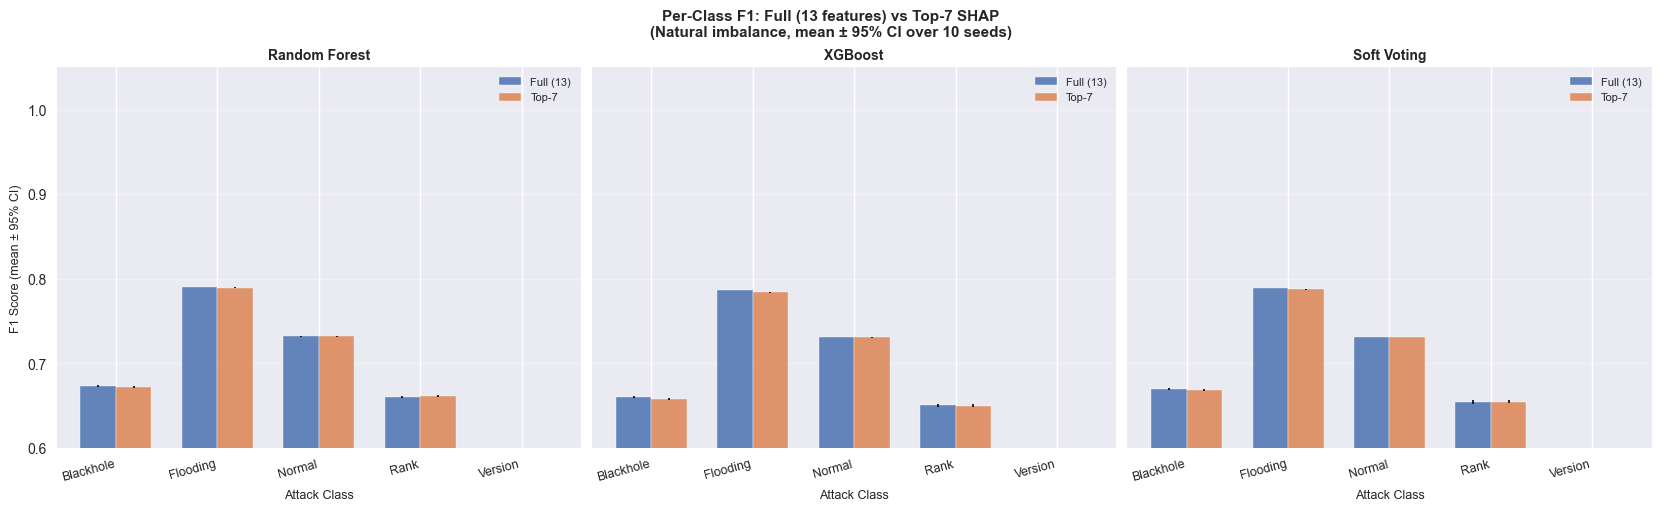


INTERPRETIVE SUMMARY — Issue 8

  SHAP ranking — Full (13) vs Top-7, XGBoost (mean over 10 seeds):
  Class           Full   Top-7     Drop
  ----------------------------------------
  Blackhole     0.6606  0.6584  +0.0022
  Flooding      0.7867  0.7842  +0.0025
  Normal        0.7310  0.7310  +0.0001
  Rank          0.6506  0.6500  +0.0006
  Version       0.4954  0.4953  +0.0000

  RFE ranking — Full (13) vs Top-7, XGBoost (mean over 10 seeds):
  Class           Full   Top-7     Drop
  ----------------------------------------
  Blackhole     0.6603  0.6557  +0.0046
  Flooding      0.7867  0.7835  +0.0032
  Normal        0.7311  0.7285  +0.0026
  Rank          0.6502  0.6474  +0.0028
  Version       0.4957  0.4943  +0.0014

  MutualInfo ranking — Full (13) vs Top-7, XGBoost (mean over 10 seeds):
  Class           Full   Top-7     Drop
  ----------------------------------------
  Blackhole     0.6605  0.6387  +0.0218  ← notable
  Flooding      0.7866  0.7621  +0.0245  ← notable
  Normal

In [5]:
# Cell 5 — Per-stratum feature-reduction analysis
# Outputs: Table3c_Per_Stratum_Results.xlsx, Figure_Per_Stratum_Grid.pdf, Figure_Per_Stratum_Subset7.pdf

import matplotlib.ticker as mticker

def run_per_stratum_full(rankings, X_train_full, y_train_full,
                         X_test, y_test, scaler, feature_names, le, results_dir):
    print("\n" + "=" * 78)
    print("ISSUE 8 — PER-STRATUM FEATURE-REDUCTION ANALYSIS")
    print("=" * 78)

    _model_names = ['Random Forest', 'XGBoost', 'Soft Voting']
    class_names  = list(le.classes_)
    n_classes    = len(class_names)

    print(f"  Models       : {_model_names}")
    print(f"  Methods      : {list(rankings.keys())}")
    print(f"  Subset sizes : {SUBSET_SIZES}")
    print(f"  Seeds        : {SEEDS}")
    print()

    # Storage: stratum_scores[method][n_feats][mname][class_idx] = [per-seed F1]
    stratum_scores = {
        method: {
            n: {mname: {c: [] for c in range(n_classes)} for mname in _model_names}
            for n in SUBSET_SIZES
        }
        for method in rankings
    }

    total_runs = len(rankings) * len(SUBSET_SIZES) * len(_model_names) * len(SEEDS)
    completed  = 0
    t_start    = time.perf_counter()

    for method, ranking in rankings.items():
        for n_feats in SUBSET_SIZES:
            feat_idx = [feature_names.index(f) for f in ranking[:n_feats]]

            for mname in _model_names:
                for seed in SEEDS:
                    X_tr_raw, y_tr = stratified_sample(
                        X_train_full, y_train_full, TRAIN_SAMPLE, seed)
                    X_tr = scaler.transform(X_tr_raw)

                    model = fresh_model(mname, seed)
                    model.fit(X_tr[:, feat_idx], y_tr)

                    y_pred     = model.predict(X_test[:, feat_idx])
                    per_cls_f1 = f1_score(y_test, y_pred,
                                          average=None, zero_division=0)

                    for c_idx, f1_val in enumerate(per_cls_f1):
                        stratum_scores[method][n_feats][mname][c_idx].append(f1_val)

                    completed += 1
                    if completed % 20 == 0:
                        elapsed = time.perf_counter() - t_start
                        eta     = elapsed / completed * (total_runs - completed)
                        print(f"  [{completed}/{total_runs}]  "
                              f"method={method}  n={n_feats}  model={mname}  "
                              f"seed={seed}  — ETA {eta/60:.1f} min")

    print(f"\n  Done. Total time: {(time.perf_counter()-t_start)/60:.1f} min")

    # ── Build results table ───────────────────────────────────────────────────
    print("\n  Building Table3c_Per_Stratum_Results …")
    rows = []
    for method in rankings:
        for n_feats in SUBSET_SIZES:
            for mname in _model_names:
                for c_idx, cls_name in enumerate(class_names):
                    scores = stratum_scores[method][n_feats][mname][c_idx]
                    m, lo, hi = bootstrap_ci(scores)
                    rows.append({
                        'Ranking Method' : method,
                        'N Features'     : n_feats,
                        'Feature Label'  : 'Full (13)' if n_feats == 13 else f'Top-{n_feats}',
                        'Model'          : mname,
                        'Attack Class'   : cls_name,
                        'F1 Mean'        : round(m,  4),
                        'CI Low'         : round(lo, 4),
                        'CI High'        : round(hi, 4),
                        'F1 Mean [CI]'   : f"{m:.4f} [{lo:.4f}, {hi:.4f}]",
                    })

    df_strat = pd.DataFrame(rows)
    save_df(df_strat, results_dir, "Table3c_Per_Stratum_Results")

    # Console summary
    for method in rankings:
        print(f"\n  ── {method} ranking ──")
        sub = df_strat[(df_strat['Ranking Method'] == method) &
                       (df_strat['Model'] == 'XGBoost')]
        pivot = sub.pivot_table(
            index='Attack Class', columns='N Features',
            values='F1 Mean', aggfunc='first')
        print(pivot.to_string())

    # ── Figure: heatmap grid (method × model) ────────────────────────────────
    print("\n  Generating Figure_Per_Stratum_Grid …")
    methods   = list(rankings.keys())
    n_methods = len(methods)
    n_models  = len(_model_names)

    fig, axes = plt.subplots(
        n_methods, n_models,
        figsize=(5 * n_models, 3.5 * n_methods),
        constrained_layout=True
    )
    if n_methods == 1: axes = axes[np.newaxis, :]
    if n_models  == 1: axes = axes[:, np.newaxis]

    vmin, vmax = 0.70, 1.00
    im = None
    for row_i, method in enumerate(methods):
        for col_j, mname in enumerate(_model_names):
            ax  = axes[row_i, col_j]
            mat = np.zeros((n_classes, len(SUBSET_SIZES)))
            for si, n_feats in enumerate(SUBSET_SIZES):
                for ci in range(n_classes):
                    mat[ci, si] = np.mean(stratum_scores[method][n_feats][mname][ci])

            im = ax.imshow(mat, aspect='auto', vmin=vmin, vmax=vmax,
                           cmap='RdYlGn', origin='upper')
            for ci in range(n_classes):
                for si in range(len(SUBSET_SIZES)):
                    ax.text(si, ci, f"{mat[ci, si]:.3f}",
                            ha='center', va='center', fontsize=7.5,
                            color='black' if mat[ci, si] > 0.82 else 'white')

            ax.set_xticks(range(len(SUBSET_SIZES)))
            ax.set_xticklabels(
                ['Full (13)' if n == 13 else f'Top-{n}' for n in SUBSET_SIZES],
                fontsize=8)
            ax.set_yticks(range(n_classes))
            ax.set_yticklabels(class_names, fontsize=8)
            ax.set_title(f"{method} / {mname}", fontsize=9, fontweight='bold')
            if row_i == n_methods - 1:
                ax.set_xlabel('Feature Subset', fontsize=8)
            if col_j == 0:
                ax.set_ylabel('Attack Class', fontsize=8)

    fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.02, pad=0.02,
                 label='F1 Score (mean over 10 seeds)')
    fig.suptitle(
        'Per-Class F1 by Feature Subset Size\n'
        '(Natural imbalance, mean over 10 seeds)',
        fontsize=11, fontweight='bold')
    save_fig(results_dir, "Figure_Per_Stratum_Grid")
    plt.show()

    # ── Figure: focused Full vs Top-7 SHAP, all models ───────────────────────
    print("  Generating Figure_Per_Stratum_Subset7 …")
    focus_method = 'SHAP'
    focus_sizes  = [13, 7]
    labels_map   = {13: 'Full (13)', 7: 'Top-7'}
    colors       = ['#4C72B0', '#DD8452']

    fig, axes2 = plt.subplots(1, n_models,
                              figsize=(5.5 * n_models, 5),
                              sharey=True, constrained_layout=True)
    if n_models == 1: axes2 = [axes2]

    x     = np.arange(n_classes)
    width = 0.35

    for ax, mname in zip(axes2, _model_names):
        for bar_i, n_feats in enumerate(focus_sizes):
            means, lo_errs, hi_errs = [], [], []
            for ci in range(n_classes):
                scores = stratum_scores[focus_method][n_feats][mname][ci]
                m, lo, hi = bootstrap_ci(scores)
                means.append(m)
                lo_errs.append(m - lo)
                hi_errs.append(hi - m)

            offset = (bar_i - 0.5) * width
            ax.bar(x + offset, means, width,
                   label=labels_map[n_feats],
                   color=colors[bar_i], alpha=0.85)
            ax.errorbar(x + offset, means,
                        yerr=[lo_errs, hi_errs],
                        fmt='none', color='black', capsize=4, linewidth=1.2)

        ax.set_xticks(x)
        ax.set_xticklabels(class_names, rotation=15, ha='right', fontsize=9)
        ax.set_ylim(0.60, 1.05)
        ax.yaxis.set_minor_locator(mticker.MultipleLocator(0.02))
        ax.grid(True, axis='y', alpha=0.35)
        ax.set_title(mname, fontsize=10, fontweight='bold')
        ax.set_xlabel('Attack Class', fontsize=9)
        if ax is axes2[0]:
            ax.set_ylabel('F1 Score (mean ± 95% CI)', fontsize=9)
        ax.legend(fontsize=8)

    fig.suptitle(
        'Per-Class F1: Full (13 features) vs Top-7 SHAP\n'
        '(Natural imbalance, mean ± 95% CI over 10 seeds)',
        fontsize=11, fontweight='bold')
    save_fig(results_dir, "Figure_Per_Stratum_Subset7")
    plt.show()

    # ── Interpretive summary ──────────────────────────────────────────────────
    print("\n" + "=" * 78)
    print("INTERPRETIVE SUMMARY — Issue 8")
    print("=" * 78)
    for method in methods:
        print(f"\n  {method} ranking — Full (13) vs Top-7, XGBoost (mean over 10 seeds):")
        print(f"  {'Class'.ljust(12)}  {'Full':>6}  {'Top-7':>6}  {'Drop':>7}")
        print("  " + "-" * 40)
        for ci, cls_name in enumerate(class_names):
            f_full = np.mean(stratum_scores[method][13]['XGBoost'][ci])
            f_red  = np.mean(stratum_scores[method][7]['XGBoost'][ci])
            drop   = f_full - f_red
            flag   = "  ← notable" if drop > 0.02 else ""
            print(f"  {cls_name.ljust(12)}  {f_full:.4f}  {f_red:.4f}  {drop:+.4f}{flag}")

    print("\n  Outputs saved:")
    print("    Table3c_Per_Stratum_Results.xlsx")
    print("    Figure_Per_Stratum_Grid.pdf")
    print("    Figure_Per_Stratum_Subset7.pdf")
    print()
    print("  Drops > 0.02 are flagged above. If all are below this threshold,")
    print("  the feature-reduction recommendation holds across all attack strata.")

    return stratum_scores


# ── Execute ──────────────────────────────────────────────────────────
stratum_scores = run_per_stratum_full(
    rankings, X_train_full, y_train_full, X_test, y_test,
    scaler, FEATURE_COLS, le, results_dir)